---

## Nodes 심화

### 노드 개념

노드는 그래프에서 실제 작업을 수행하는 함수입니다.

### 노드 함수 매개변수

노드 함수는 최대 3가지 매개변수를 받을 수 있습니다:

| 매개변수 | 타입 | 설명 |
|----------|------|------|
| `state` | State | 현재 그래프 상태 (필수) |
| `config` | RunnableConfig | 실행 시점 설정 정보 (선택) |
| `store` | BaseStore | 런타임 리소스 접근 (선택) |

**사용 예시**

```python
# state만 사용
def simple_node(state: MyState):
    return {"count": state["count"] + 1}

# state + config 사용
def config_node(state: MyState, config: RunnableConfig):
    user_id = config["configurable"]["user_id"]
    return {"user": user_id}

# 모든 매개변수 사용
def advanced_node(state: MyState, config: RunnableConfig, *, store: BaseStore):
    data = store.get(state["key"])
    return {"data": data}
```

### Config 스키마

ConfigSchema는 노드가 받을 수 있는 설정값의 타입을 정의합니다. TypedDict나 dataclass를 사용하여 스키마를 정의하면, 잘못된 설정 키 이름을 방지하고 타입 안전성을 보장받을 수 있습니다.

아래 코드는 ConfigSchema를 정의하고 노드에서 활용하는 방법을 보여줍니다.

In [1]:
from feature.ConfigSchema import ConfigSchema, ConfigSchemaState, SimpleConfigSchema


workflow = SimpleConfigSchema()


LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


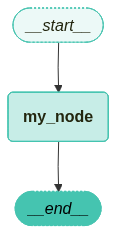

In [2]:
workflow.show_graph()

In [4]:
from langchain_core.messages import HumanMessage


workflow.invoke(
    {"messages": [HumanMessage(content="안녕하세요")]},
    config={
        "configurable": {"runtime_value": "I love LangGraph", "setting_value": 123}
    },
)

runtime_value: I love LangGraph
setting_value: 123
state: {'messages': [HumanMessage(content='안녕하세요', additional_kwargs={}, response_metadata={}, id='907c5536-e02d-42ce-8606-bdbc1ab434b3')]}

🔄 Node: my_node 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
updated_key:
new_value


{'messages': [HumanMessage(content='안녕하세요', additional_kwargs={}, response_metadata={}, id='907c5536-e02d-42ce-8606-bdbc1ab434b3')],
 'updated_key': 'new_value'}